In [96]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text

In [97]:
csv_files = sorted(Path(".").glob("results*.csv"))
if not csv_files:
    raise FileNotFoundError("Nebyl nalezen zadny soubor results*.csv")

frames = []
for csv_file in csv_files:
    part = pd.read_csv(csv_file)
    part["source_file"] = csv_file.name
    depth_match = re.search(r"d(\d+)", csv_file.stem)
    frames.append(part)

df = pd.concat(frames, ignore_index=True)
depth_label = df["max_depth"].apply(lambda d: f"d={d}" if pd.notna(d) else "")
df["solver_label"] = df["solver"] + depth_label.apply(lambda x: f" ({x})" if x else "")

df


,solver,max_depth,games,best_score,worst_score,avg_score,wins,losses,avg_max_tile,avg_moves_total,avg_moves_up,avg_moves_down,avg_moves_left,avg_moves_right,total_moves,source_file,solver_label
0,random,NaN,100,2824,292,1140.76,0,100,110.40,121.73,38.12,30.47,24.52,28.62,12173,results-d1.csv,random
1,priority_corner,NaN,100,5920,628,2458.48,0,100,195.84,219.43,10.51,54.85,153.92,0.15,21943,results-d1.csv,priority_corner
2,alpha_beta,1.0,100,11356,724,3687.84,0,100,266.24,292.66,1.69,153.56,71.46,65.95,29266,results-d1.csv,alpha_beta (d=1.0)
3,expectiminimax,1.0,100,11816,840,3609.60,0,100,261.76,288.73,1.52,148.29,70.86,68.06,28873,results-d1.csv,expectiminimax (d=1.0)
4,random,NaN,100,2980,212,1170.60,0,100,115.20,122.62,29.53,33.48,28.47,31.14,12262,results-d2.csv,random
5,priority_corner,NaN,100,6888,544,2583.00,0,100,204.16,227.50,10.76,57.02,159.57,0.15,22750,results-d2.csv,priority_corner
6,alpha_beta,2.0,100,24196,3072,13267.00,19,81,1013.76,768.12,5.61,342.14,214.71,205.66,76812,results-d2.csv,alpha_beta (d=2.0)
7,expectiminimax,2.0,100,24268,3328,13098.52,24,76,1062.40,746.66,6.46,332.28,201.91,206.01,74666,results-d2.csv,expectiminimax (d=2.0)
8,random,NaN,100,2692,312,1119.08,0,100,109.44,120.04,27.12,32.93,28.50,31.49,12004,results-d3.csv,random
9,priority_corner,NaN,100,5500,560,2429.88,0,100,193.60,217.71,10.31,54.05,153.25,0.10,21771,results-d3.csv,priority_corner


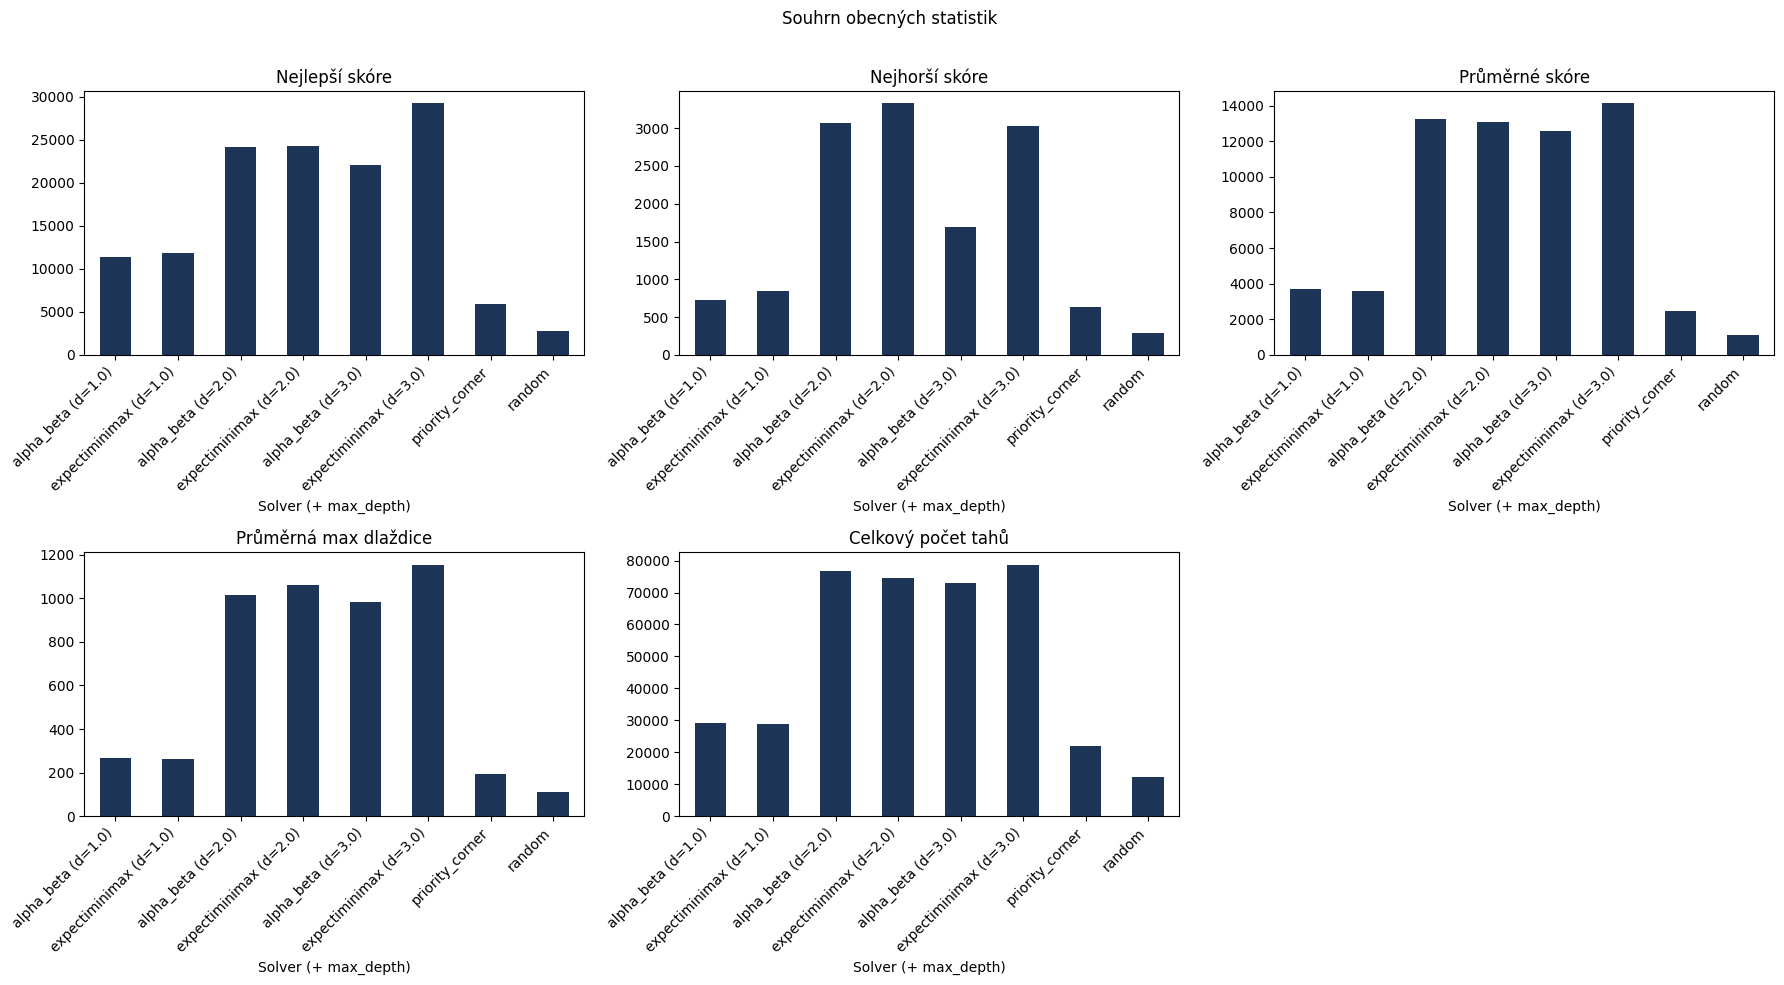

In [98]:
summary_cols = [
    "solver_label",
    "source_file",
    "solver",
    "max_depth",
    "games",
    "avg_score",
    "best_score",
    "worst_score",
    "wins",
    "losses",
    "avg_max_tile",
]
df[summary_cols].sort_values(["solver_label"], ascending=[True])
df = df.drop_duplicates(subset=["solver_label"])

metric_labels = {
    "best_score": "Nejlepší skóre",
    "worst_score": "Nejhorší skóre",
    "avg_score": "Průměrné skóre",
    "avg_max_tile": "Průměrná max dlaždice",
    "total_moves": "Celkový počet tahů",
}

plot_df = df.sort_values(["max_depth", "solver"], na_position="last")
single_metrics = [m for m in metric_labels if m in plot_df.columns]
plot_count = len(single_metrics)

ncols = 3
nrows = max(1, (plot_count + ncols - 1) // ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows), squeeze=False)

def style_axis(ax, title):
    ax.set_title(title)
    ax.set_xlabel("Solver (+ max_depth)")
    ax.tick_params(axis="x", labelrotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")

plot_idx = 0
for metric in single_metrics:
    ax = axes[plot_idx // ncols][plot_idx % ncols]
    plot_df.set_index("solver_label")[metric].plot(
        kind="bar", ax=ax, legend=False, color="#1d3557"
    )
    style_axis(ax, metric_labels[metric])
    plot_idx += 1

for idx in range(plot_idx, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("Souhrn obecných statistik")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

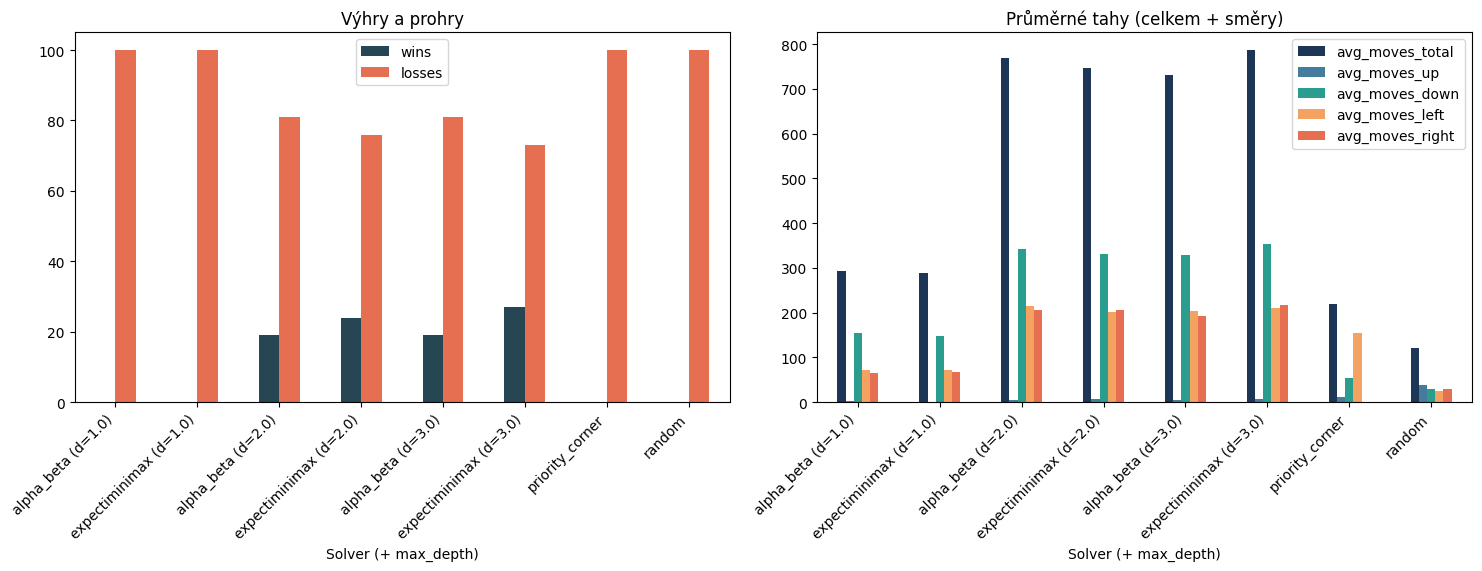

In [99]:
plot_df = df.sort_values(["max_depth", "solver"], na_position="last")
wins_loss_cols = [c for c in ["wins", "losses"] if c in plot_df.columns]
avg_move_cols = [
    c
    for c in ["avg_moves_total", "avg_moves_up", "avg_moves_down", "avg_moves_left", "avg_moves_right"]
    if c in plot_df.columns
]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), squeeze=False)

def style_axis(ax, title):
    ax.set_title(title)
    ax.set_xlabel("Solver (+ max_depth)")
    ax.tick_params(axis="x", labelrotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")

plot_idx = 0
ax = axes[0][plot_idx]
plot_df.set_index("solver_label")[wins_loss_cols].plot(
    kind="bar",
    ax=ax,
    color=["#264653", "#e76f51"][: len(wins_loss_cols)],
)
style_axis(ax, "Výhry a prohry")
ax.legend(title="")
plot_idx += 1

ax = axes[0][plot_idx]
plot_df.set_index("solver_label")[avg_move_cols].plot(
    kind="bar",
    ax=ax,
    color=["#1d3557", "#457b9d", "#2a9d8f", "#f4a261", "#e76f51"][: len(avg_move_cols)],
)
style_axis(ax, "Průměrné tahy (celkem + směry)")
ax.legend(title="")
plot_idx += 1

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

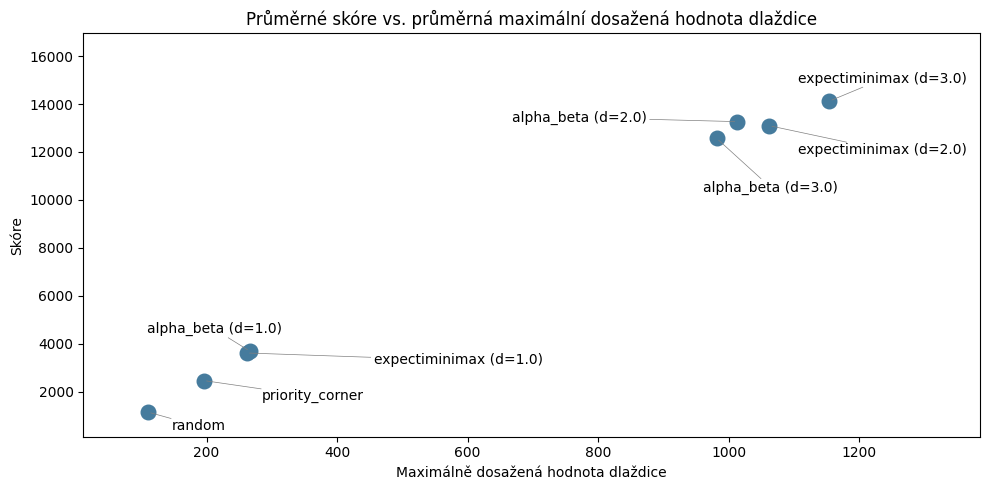

In [100]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df["avg_max_tile"], df["avg_score"], s=110, c="#457b9d")

texts = []

for _, row in df.iterrows():
    depth_part = f" d={row['max_depth']}" if pd.notna(row["max_depth"]) else ""
    label = f"{row['solver_label']}"
    t = ax.text(row["avg_max_tile"], row["avg_score"], label)
    texts.append(t)

ax.set_title("Průměrné skóre vs. průměrná maximální dosažená hodnota dlaždice")
ax.set_xlabel("Maximálně dosažená hodnota dlaždice")
ax.set_ylabel("Skóre")

ax.set_xlim(right=df["avg_max_tile"].max() * 1.2, left=df["avg_max_tile"].min() * 0.1)
ax.set_ylim(top=df["avg_score"].max() * 1.2, bottom=df["avg_score"].min() * 0.1)

ax.margins(x=0.15, y=0.15)

adjust_text(texts,
            arrowprops=dict(arrowstyle="-", color='gray', lw=0.5),
            expand=(2, 2))

plt.tight_layout()
plt.show()